# Lecture 4 participant notebook: Equivariant layers

This notebook assembles the CG tensor-product layer. Focus on which axes are fixed by symmetry and
which axes carry learned weights.

In [51]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def random_rotation(rng):
    """Return a random proper 3D rotation using a unit quaternion."""
    q = rng.normal(size=4)
    q /= np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)],
    ])

In [52]:
# Spherical basis and Wigner D matrices
# Shared setup, identical in Lectures 2-5. Lecture 2 walks through it line by
# line; in later lectures just run it and move on.
from sympy.physics.wigner import clebsch_gordan  # Load tabulated CG coefficients from SymPy.

SQ2 = np.sqrt(2.0)  # Store sqrt(2), which appears repeatedly in the spherical basis.
U1 = np.array([  # Define the unitary change of basis from Cartesian (x,y,z) to m=(-1,0,+1).
    [1/SQ2, -1j/SQ2, 0],   # m=-1: v_-1 = (v_x - i v_y)/sqrt(2).
    [0,      0,       1],   # m= 0: v_0  = v_z.
    [-1/SQ2, -1j/SQ2, 0],  # m=+1: v_+1 = -(v_x + i v_y)/sqrt(2).
], dtype=complex)  # Spherical components are complex even for a real Cartesian vector.

def cart_to_sph(v):
    """Convert Cartesian vectors to spherical l=1 components.

    Inputs
    ------
    v : array, shape (..., 3)
        Real or complex vectors whose final axis is ordered (x, y, z).

    Returns
    -------
    array, shape (..., 3)
        Complex spherical components ordered by m=(-1, 0, +1).
    """
    v = np.asarray(v)  # Accept a list or ndarray and preserve any leading batch axes.
    return v @ U1.T  # Apply U1 to the final axis; row-vector storage requires the transpose.

def sph_to_cart(v_sph):
    """Convert spherical l=1 components back to Cartesian vectors.

    Inputs
    ------
    v_sph : array, shape (..., 3)
        Spherical components ordered by m=(-1, 0, +1).

    Returns
    -------
    array, shape (..., 3)
        Cartesian components ordered (x, y, z); physical real vectors become real arrays.
    """
    v_sph = np.asarray(v_sph)  # Accept a list or ndarray and preserve leading axes.
    v_cart = v_sph @ U1.conj()  # Apply U1^dagger; row-vector storage gives U1.conjugate().
    return np.real_if_close(v_cart, tol=1000)  # Remove round-off-sized imaginary parts only.

def cg_tensor(l1, l2, L):
    """Load one Clebsch-Gordan coupling tensor in the spherical basis.

    Inputs
    ------
    l1, l2 : int
        Angular momenta of the two input irreps.
    L : int
        Angular momentum of the coupled output irrep.

    Returns
    -------
    C : complex array, shape (2*L+1, 2*l1+1, 2*l2+1)
        C[M+L,m1+l1,m2+l2] equals <l1 m1,l2 m2 | L M>, including the
        fixed phase that preserves the reality convention for physical tensors.
    """
    C = np.zeros((2*L+1, 2*l1+1, 2*l2+1), dtype=complex)  # Allocate axes (M,m1,m2).
    for M in range(-L, L+1):  # Visit each output magnetic index M=-L,...,+L.
        for m1 in range(-l1, l1+1):  # Visit each magnetic index of the first input.
            m2 = M - m1  # The selection rule M=m1+m2 fixes the second magnetic index.
            if -l2 <= m2 <= l2:  # Skip combinations outside the second irrep's valid range.
                coefficient = clebsch_gordan(l1, l2, L, m1, m2, M)  # Ask SymPy for the CGC.
                C[M+L, m1+l1, m2+l2] = float(coefficient)  # Store it using zero-based indices.
    reality_phase = (-1j)**(l1+l2-L)  # Choose the phase making real inputs map to real tensors.
    return reality_phase * C  # Return fixed representation data, not a learnable parameter.

L_MAX = 2  # Highest irrep this course carries. This is a budget choice, NOT a symmetry
           # rule: the triangle rule genuinely allows 1x2->3 and 2x2->3,4, and we simply
           # do not build them. Raise L_MAX to get them, at rising cost.

CG = {}  # Map every allowed key (l1,l2,L) to its fixed Clebsch-Gordan tensor.
for l1 in range(L_MAX+1):  # Include first-input irreps l1=0,...,L_MAX.
    for l2 in range(l1, L_MAX+1):  # Store only l1<=l2; cg_product handles the reversed order.
        for L in range(abs(l1-l2), min(l1+l2, L_MAX)+1):  # Triangle rule, then truncate at L_MAX.
            CG[(l1, l2, L)] = cg_tensor(l1, l2, L)  # Load this coupling from SymPy once.

def D_sph(l, R):
    """Construct the Wigner D matrix for a 3D rotation.

    Inputs
    ------
    l : int
        Irrep degree; this compact example supports l=0,1,2.
    R : array, shape (3, 3)
        Active Cartesian rotation matrix acting as v_rotated = R @ v.

    Returns
    -------
    D : complex array, shape (2*l+1, 2*l+1)
        Wigner D^l(R), acting on m=-l,...,+l spherical components.
    """
    if l == 0:  # A scalar has one component and is unchanged by every rotation.
        return np.ones((1, 1), dtype=complex)  # D^0(R)=1.
    R = np.asarray(R)  # Normalize the input to an ndarray before matrix multiplication.
    D1 = U1 @ R @ U1.conj().T  # Rewrite the Cartesian rotation in the spherical l=1 basis.
    if l == 1:  # A spherical vector transforms directly with this 3x3 matrix.
        return D1  # Return D^1(R).
    if l == 2:  # Build the five-dimensional irrep from the 1 tensor 1 -> 2 coupling.
        C112 = CG[(1, 1, 2)]  # Fetch the fixed CG tensor selecting total angular momentum L=2.
        return np.einsum('Mab,ai,bj,Nij->MN', C112, D1, D1, C112.conj())  # C (D1 x D1) C^dagger;
        # the conjugate matters: C(1,1,2) happens to be real, but a coupling whose
        # phase (-i)^(l1+l2-L) is odd is not, and C^T would then be the wrong matrix.
    raise ValueError("this compact example implements l=0,1,2")  # Reject unsupported irreps.

def rotate_sph_features(features, R):
    """Rotate every multiplet in a feature dictionary.

    Inputs
    ------
    features : dict[int, array(batch, channels, 2*l+1)]
        Spherical features grouped by irrep degree l.
    R : array, shape (3, 3)
        Cartesian rotation applied to every sample and channel.

    Returns
    -------
    dict[int, array(batch, channels, 2*l+1)]
        A new dictionary with D^l(R) applied along every magnetic-index axis.
    """
    rotated = {}  # Create a new dictionary so the input features are not modified.
    for l, values in features.items():  # Process each irrep block independently.
        Dl = D_sph(l, R)  # Obtain the correct generalized rotation for this l.
        rotated[l] = np.einsum('mn,bcn->bcm', Dl, values)  # Contract D's input m with the feature m.
    return rotated  # Return all rotated irrep blocks.

v_cart = rng.normal(size=(5, 3))  # Draw five real Cartesian vectors for a round-trip test.
v_reconstructed = sph_to_cart(cart_to_sph(v_cart))  # Convert Cartesian -> spherical -> Cartesian.
roundtrip_error = np.max(np.abs(v_reconstructed - v_cart))  # Compare reconstruction to the original.
print(f"Cartesian <-> spherical round-trip: {roundtrip_error:.1e}")  # Expect floating-point error.

Ra = random_rotation(rng)  # Draw the first rotation used in the representation-law check.
Rb = random_rotation(rng)  # Draw the second rotation used in the representation-law check.
for l in (0, 1, 2):  # Test every irrep implemented in this example.
    hom = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Rb) - D_sph(l, Ra @ Rb)))  # Check D(Ra)D(Rb)=D(RaRb).
    unit = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Ra).conj().T - np.eye(2*l+1)))  # Check D D^dagger=I.
    print(f"l={l}: representation {hom:.1e}, unitary {unit:.1e}")  # Both errors should be near 1e-15.

Cartesian <-> spherical round-trip: 2.2e-16
l=0: representation 0.0e+00, unitary 0.0e+00
l=1: representation 2.2e-16, unitary 1.2e-16
l=2: representation 3.3e-16, unitary 2.2e-16


In [53]:
# Verify that each CG tensor is an equivariant map
def cg_product(x, y, l1, l2, L):
    """Couple two spherical multiplets into total angular momentum L.

    Inputs
    ------
    x : array, shape (..., 2*l1+1)
        First spherical feature, ordered by m1=-l1,...,+l1.
    y : array, shape (..., 2*l2+1)
        Second spherical feature, ordered by m2=-l2,...,+l2.
    l1, l2 : int
        Irrep degrees of x and y.
    L : int
        Requested output irrep, satisfying |l1-l2| <= L <= l1+l2.

    Returns
    -------
    array, shape (..., 2*L+1)
        Coupled spherical feature ordered by M=-L,...,+L.
    """
    if l1 <= l2:  # CG stores only keys with the smaller irrep first.
        key = (l1, l2, L)  # Use the stored order directly.
        swap = False  # The tensor's m axes already match x and y.
    else:  # Reverse the lookup order when l1>l2.
        key = (l2, l1, L)  # Look up the canonical stored key.
        swap = True  # Record that the two input axes must be exchanged.
    C = CG[key]  # Fetch the fixed Clebsch-Gordan tensor.
    if swap:  # Align the tensor axes with the actual x,y order.
        # Exchanging the two irreps is not just an axis swap; it costs a sign, because
        # <l1 m1, l2 m2 | L M> = (-1)^(l1+l2-L) <l2 m2, l1 m1 | L M>.
        C = C.swapaxes(1, 2) * (-1.0)**(l1+l2-L)  # Swap the m axes and apply that sign.
    return np.einsum('Mij,...i,...j->...M', C, x, y)  # Sum C[M,m1,m2]x[m1]y[m2].

R = random_rotation(rng)  # Use one common rotation for all CG equivariance tests.
paths = [(1,1,0), (1,1,1), (1,1,2), (1,2,1), (2,2,2)]  # Select representative legal couplings.
print("  path          max |CG(Dx,Dy)-D CG(x,y)|")  # Label the residual printed below.
for l1, l2, L in paths:  # Test one input/output irrep combination at a time.
    x = rng.normal(size=2*l1+1) + 1j*rng.normal(size=2*l1+1)  # Draw a generic complex l1 multiplet.
    y = rng.normal(size=2*l2+1) + 1j*rng.normal(size=2*l2+1)  # Draw a generic complex l2 multiplet.
    x_rot = D_sph(l1, R) @ x  # Rotate x using the Wigner matrix for l1.
    y_rot = D_sph(l2, R) @ y  # Rotate y using the Wigner matrix for l2.
    lhs = cg_product(x_rot, y_rot, l1, l2, L)  # Route 1: rotate inputs, then couple them.
    coupled = cg_product(x, y, l1, l2, L)  # Couple the original inputs into an L multiplet.
    rhs = D_sph(L, R) @ coupled  # Route 2: couple first, then rotate the output.
    residual = np.max(np.abs(lhs-rhs))  # Equivariance requires the two routes to agree.
    print(f" {l1} x {l2} -> {L}              {residual:.1e}")  # Expect about machine precision.

  path          max |CG(Dx,Dy)-D CG(x,y)|
 1 x 1 -> 0              0.0e+00
 1 x 1 -> 1              1.5e-16
 1 x 1 -> 2              9.9e-16
 1 x 2 -> 1              6.2e-16
 2 x 2 -> 2              5.0e-16


## 0. What the two layer functions do (Just check the figure, don't read the code)

The next section builds `layer_forward` and `gate_forward`. Here is what they are, before the code: **`layer_forward` is the linear algebra, `gate_forward` is the nonlinearity**, and the constraint that makes both equivariant is visible in the shapes.

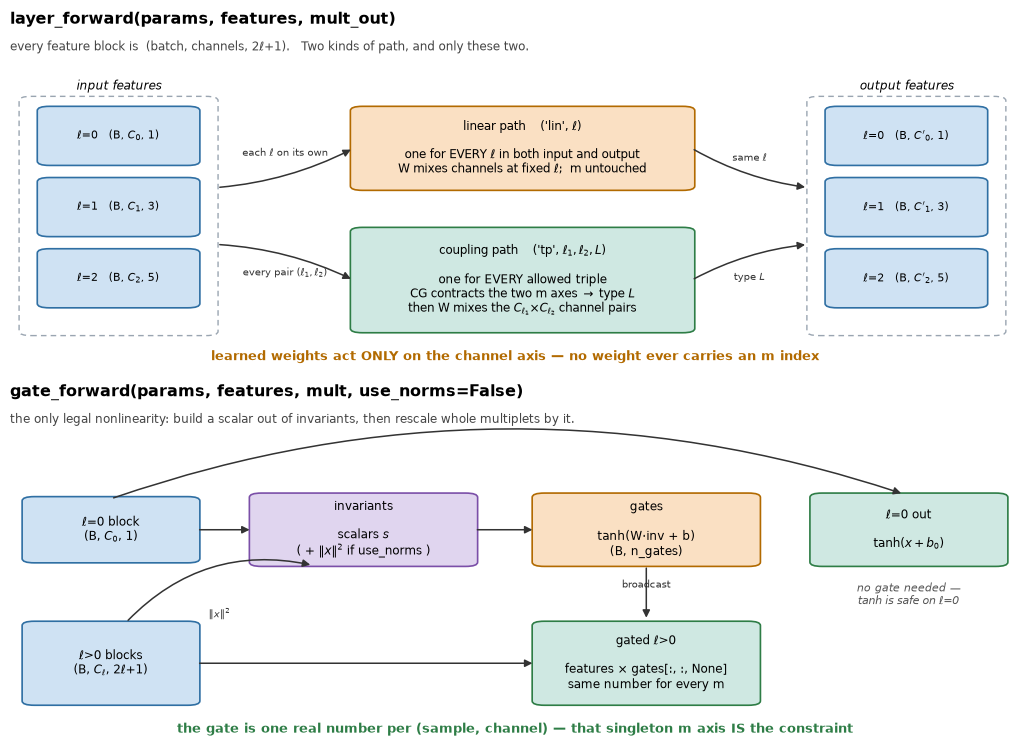

In [54]:
# What the two layer functions actually do
# A picture of the next cell, before you read it. Nothing here is used later;
# it is a diagram, drawn with matplotlib so it travels with the notebook.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BLUE, TEAL, ORANGE, PURPLE = "#cfe2f3", "#cfe8e2", "#fae0c3", "#e0d5ef"
EDGE = {BLUE: "#2F6FA3", TEAL: "#2E7D46", ORANGE: "#B26A00", PURPLE: "#7B4FA8"}

def box(ax, x, y, w, h, text, fc, fs=8.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008,rounding_size=0.012",
                                fc=fc, ec=EDGE[fc], lw=1.2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)

def arrow(ax, p, q, text=None, fs=7.5, rad=0.0, dy=0.022):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=11, lw=1.1,
                                 color="#333333", connectionstyle=f"arc3,rad={rad}"))
    if text:
        ax.text((p[0]+q[0])/2, (p[1]+q[1])/2 + dy, text, ha="center", va="bottom",
                fontsize=fs, color="#333333")

fig, axes = plt.subplots(2, 1, figsize=(10.4, 7.6))
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

ax = axes[0]
ax.text(0.0, 0.96, "layer_forward(params, features, mult_out)", fontsize=11.5, weight="bold")
ax.text(0.0, 0.885, "every feature block is  (batch, channels, 2$\\ell$+1).   Two kinds of path, and only these two.",
        fontsize=8.5, color="#444444")

# input group -------------------------------------------------------------
ax.add_patch(FancyBboxPatch((0.015, 0.09), 0.185, 0.66, boxstyle="round,pad=0.006,rounding_size=0.012",
                            fc="none", ec="#9aa5b1", lw=1.0, ls=(0, (4, 3))))
for k, (l, d) in enumerate([(0, 1), (1, 3), (2, 5)]):
    box(ax, 0.035, 0.57 - k*0.20, 0.145, 0.15, f"$\\ell$={l}   (B, $C_{l}$, {d})", BLUE, fs=8)
ax.text(0.108, 0.775, "input features", fontsize=8.5, ha="center", style="italic")

box(ax, 0.345, 0.50, 0.325, 0.22,
    "linear path    ('lin', $\\ell$)\n\none for EVERY $\\ell$ in both input and output\n"
    "W mixes channels at fixed $\\ell$;  m untouched", ORANGE, fs=8.3)
box(ax, 0.345, 0.10, 0.325, 0.28,
    "coupling path    ('tp', $\\ell_1,\\ell_2,L$)\n\none for EVERY allowed triple\n"
    "CG contracts the two m axes $\\rightarrow$ type $L$\nthen W mixes the $C_{\\ell_1}\\!\\times\\!C_{\\ell_2}$ channel pairs",
    TEAL, fs=8.3)

arrow(ax, (0.205, 0.50), (0.340, 0.61), rad=0.10)
arrow(ax, (0.205, 0.34), (0.340, 0.24), rad=-0.10)
ax.text(0.2725, 0.588, "each $\\ell$ on its own", fontsize=7.2, ha="center", color="#333333")
ax.text(0.2725, 0.252, "every pair ($\\ell_1,\\ell_2$)", fontsize=7.2, ha="center", color="#333333")

# output group ------------------------------------------------------------
ax.add_patch(FancyBboxPatch((0.795, 0.09), 0.185, 0.66, boxstyle="round,pad=0.006,rounding_size=0.012",
                            fc="none", ec="#9aa5b1", lw=1.0, ls=(0, (4, 3))))
for k, (l, d) in enumerate([(0, 1), (1, 3), (2, 5)]):
    box(ax, 0.815, 0.57 - k*0.20, 0.145, 0.15, f"$\\ell$={l}   (B, $C'_{l}$, {d})", BLUE, fs=8)
ax.text(0.888, 0.775, "output features", fontsize=8.5, ha="center", style="italic")
arrow(ax, (0.675, 0.61), (0.790, 0.50), rad=0.10, text="same $\\ell$", fs=7.2, dy=0.012)
arrow(ax, (0.675, 0.24), (0.790, 0.34), rad=-0.10, text="type $L$", fs=7.2, dy=-0.06)

ax.text(0.50, 0.015, "learned weights act ONLY on the channel axis — no weight ever carries an m index",
        fontsize=9, ha="center", color="#B26A00", weight="bold")

ax = axes[1]
ax.text(0.0, 0.96, "gate_forward(params, features, mult, use_norms=False)", fontsize=11.5, weight="bold")
ax.text(0.0, 0.885, "the only legal nonlinearity: build a scalar out of invariants, then rescale whole multiplets by it.",
        fontsize=8.5, color="#444444")

box(ax, 0.02, 0.50, 0.16, 0.17, "$\\ell$=0 block\n(B, $C_0$, 1)", BLUE)
box(ax, 0.02, 0.10, 0.16, 0.22, "$\\ell$>0 blocks\n(B, $C_\\ell$, 2$\\ell$+1)", BLUE)
box(ax, 0.245, 0.49, 0.21, 0.19, "invariants\n\nscalars $s$\n( + $\\|x\\|^2$ if use_norms )", PURPLE)
box(ax, 0.525, 0.49, 0.21, 0.19, "gates\n\ntanh(W·inv + b)\n(B, n_gates)", ORANGE)
box(ax, 0.80, 0.49, 0.18, 0.19, "$\\ell$=0 out\n\ntanh($x + b_0$)", TEAL)
box(ax, 0.525, 0.10, 0.21, 0.22, "gated $\\ell$>0\n\nfeatures $\\times$ gates[:, :, None]\nsame number for every m", TEAL)

arrow(ax, (0.185, 0.585), (0.24, 0.585))
arrow(ax, (0.46, 0.585), (0.52, 0.585))
arrow(ax, (0.10, 0.672), (0.885, 0.685), rad=-0.17)
ax.text(0.89, 0.44, "no gate needed —\ntanh is safe on $\\ell$=0", fontsize=7.6,
        ha="center", va="top", color="#555555", style="italic")
arrow(ax, (0.115, 0.325), (0.30, 0.485), rad=-0.28, text="$\\|x\\|^2$", dy=-0.075)
arrow(ax, (0.63, 0.485), (0.63, 0.33), text="broadcast", dy=0.008)
arrow(ax, (0.185, 0.21), (0.52, 0.21))
ax.text(0.50, 0.015, "the gate is one real number per (sample, channel) — that singleton m axis IS the constraint",
        fontsize=9, ha="center", color="#2E7D46", weight="bold")

fig.tight_layout()
plt.show()  # Display inline.


## 1. Build the layer and inspect its parameter paths

In [55]:
# Equivariant tensor-product network
def allowed(l1, l2, L):
    """Return whether l1 tensor l2 contains output irrep L.

    Inputs: integer angular momenta l1, l2, and L.
    Returns: bool implementing the SO(3) triangle rule.
    """
    return abs(l1-l2) <= L <= l1+l2  # SO(3) permits exactly this range of total angular momenta.

def layer_spec(mult_in, mult_out):
    """Describe every learnable weight array in one equivariant layer.

    Inputs
    ------
    mult_in, mult_out : dict[int, int]
        Number of input/output channels (multiplicities) for each irrep l.

    Returns
    -------
    spec : dict[tuple, tuple]
        Maps each linear or tensor-product path to its learnable weight shape.
    """
    spec = {}  # Collect parameter names and shapes without allocating their values yet.
    
    shared_irreps = sorted(set(mult_in) & set(mult_out))  # Find l values present at input and output.
    for l in shared_irreps:  # Add an equivariant linear path within each shared irrep. <= Eq. (1) from the lecture note
        spec[('lin', l)] = (mult_out[l], mult_in[l])  # Mix channels while leaving the m axis untouched.
        
    for l1 in sorted(mult_in):  # Choose the first irrep entering a bilinear CG product.
        for l2 in sorted(mult_in):  # Choose the second irrep entering that product.
            if l2 < l1:  # Avoid listing the same unordered irrep pair twice.
                continue  # The l2<l1 version is represented through the canonical order.
                
            for L in sorted(mult_out):  # Consider each requested output irrep. <= Eq. (4) from the lecture note
                if allowed(l1, l2, L) and max(l1, l2, L) <= L_MAX:  # Keep legal paths supported here.
                    n_pairs = mult_in[l1] * mult_in[l2]  # Count all pairs of input channels.
                    spec[('tp', l1, l2, L)] = (mult_out[L], n_pairs)  # Learn how to mix path channels.
                    
    return spec  # This dictionary completely specifies the layer's trainable architecture.

def layer_forward(params, features, mult_out, cgs=CG):
    """Apply equivariant linear and CG tensor-product paths.

    Inputs
    ------
    params : dict[tuple, array]
        Learnable channel-mixing matrices produced from layer_spec.
    features : dict[int, array(batch, channels, 2*l+1)]
        Input spherical features grouped by irrep degree.
    mult_out : dict[int, int]
        Requested output channel count for every output irrep.
    cgs : dict, optional
        Fixed CG tensors; injectable only so Section 2 can deliberately corrupt one.

    Returns
    -------
    out : dict[int, complex array(batch, channels_out, 2*l+1)]
        Output spherical feature multiplets.
    """
    batch = next(iter(features.values())).shape[0]  # Read the common batch size from any irrep block.
    out = {}  # Allocate one accumulator for every requested output irrep.
    
    for l, channels in mult_out.items():  # Visit each output type and its multiplicity.
        out[l] = np.zeros((batch, channels, 2*l+1), dtype=complex)  # Axes are (batch,channel,m).
        
    for key, weights in params.items():  # Accumulate the contribution of every allowed path.
        if key[0] == 'lin':  # This path mixes channels inside a single irrep.
            l = key[1]  # Read which irrep the linear path acts on.
            out[l] += np.einsum('oc,bcm->bom', weights, features[l])  # Contract channels, preserve m. <= Eq. (1) from the lecture note
            
        else:  # This path couples two irreps through a fixed CG tensor.
            _, l1, l2, L = key  # Decode the input and output angular momenta from the key.
            C = cgs[(l1, l2, L)]  # Fetch C[M,m1,m2] for this coupling.
            products = np.einsum('Mij,bci,bdj->bcdM', C, features[l1], features[l2])  # Apply CG to m axes. <= Eq. (3) from the lecture note
            products = products.reshape(batch, -1, 2*L+1)  # Flatten the two input-channel axes.
            out[L] += np.einsum('op,bpM->boM', weights, products)  # Learnably mix products, preserve M. <= Eq. (4) from the lecture note
    return out  # Return all output irreps after summing their legal paths.

def gate_spec(mult, use_norms=False):
    """Specify parameters for invariant scalar nonlinearities and gates.

    Inputs: mult, a dict mapping each l to its channel count; use_norms, whether the gate
    may also see the squared norm of each l>0 channel.
    Returns: shapes for scalar biases and the gate's weight matrix and bias.
    """
    n_gates = sum(channels for l, channels in mult.items() if l > 0)  # One gate per non-scalar channel.
    n_inv = mult[0] + (n_gates if use_norms else 0)  # What the gate is allowed to look at.
    return {'b0': (mult[0],), 'Wg': (n_gates, n_inv), 'bg': (n_gates,)}  # Declare all gate parameters.

def gate_forward(params, features, mult, use_norms=False):
    """Apply symmetry-safe nonlinearities to a feature dictionary.

    Inputs
    ------
    params : dict[str, array]
        Scalar biases b0 plus gate weights Wg and gate biases bg.
    features : dict[int, array(batch, channels, 2*l+1)]
        Spherical features containing an l=0 block.
    mult : dict[int, int]
        Channel counts for the feature dictionary.
    use_norms : bool
        If True the gate also sees ||x||^2 for every l>0 channel, which is invariant because
        D^(l) is unitary. Must match the flag passed to gate_spec.

    Returns
    -------
    gated : dict with the same shapes as features
        Scalars pass through tanh; each l>0 multiplet is scaled uniformly over m.
    """
    scalars = features[0][:, :, 0].real  # Extract invariant l=0 values with shape (batch,channels_0).
    scalar_output = np.tanh(features[0].real + params['b0'][None, :, None])  # Nonlinearity is safe on l=0.
    gated = {0: scalar_output.astype(complex)}  # Keep a uniform complex dtype across irrep blocks.
    
    invariants = scalars  # The l=0 block is invariant by construction.
    if use_norms:  # Optionally widen what the gate may depend on.
        norms = np.concatenate([np.sum(np.abs(features[l])**2, axis=2)  # ||x||^2 per l>0 channel,
                                for l in sorted(mult) if l > 0], axis=1)  # invariant and free to form.
        invariants = np.concatenate([scalars, norms], axis=1)  # Same channel order as gate_spec.
        
    gate_logits = np.einsum('oc,bc->bo', params['Wg'], invariants) + params['bg']  # Map invariants to gates.
    gates = np.tanh(gate_logits)  # tanh(w . invariants + b): a learned affine map.

    offset = 0  # Track which gate columns belong to the current non-scalar irrep.
    for l in sorted(mult):  # Visit irrep blocks in the same order used by gate_spec.
        if l == 0:  # The scalar block was handled separately above.
            continue  # Do not gate it a second time.
        width = mult[l]  # Read how many channels this irrep owns.
        block_gates = gates[:, offset:offset+width, None]  # Add a singleton m axis for broadcasting.
        gated[l] = features[l] * block_gates  # Scale every m component of a channel by one invariant.
        offset += width  # Advance to the gates for the next irrep block.
    return gated  # Return nonlinear features without violating equivariance.

M_IN = {1: 2}  # Input: two l=1 channels, representing vectors u and v.
M_HID = {0: 2, 1: 2, 2: 2}  # Hidden state: two channels each of scalars, vectors, and quadrupoles.
M_OUT = {1: 1}  # Output: one l=1 channel, representing the predicted vector.
SPECS = [layer_spec(M_IN, M_HID), gate_spec(M_HID), layer_spec(M_HID, M_OUT)]  # Describe layer, gate, layer.

def init_params(specs, rng, scale=0.4):
    """Initialize real learnable channel weights.

    Inputs: specs from layer_spec/gate_spec, NumPy RNG, and Gaussian scale.
    Returns: list of parameter dictionaries matching the supplied specs.
    """
    params = []  # Build one parameter dictionary for each architecture block.
    for spec in specs:  # Initialize blocks in forward-pass order.
        block = {}  # Hold every array belonging to this block.
        for key, shape in spec.items():  # Visit each named parameter and its requested shape.
            block[key] = rng.normal(size=shape) * scale  # Draw independent real Gaussian weights.
        params.append(block)  # Keep this initialized block.
    return params  # Return [first_layer, gate, second_layer] parameters.

def flatten(params):
    """Flatten a list of parameter dictionaries into one optimization vector.

    Input: params, a list of dictionaries of ndarrays.
    Returns: one-dimensional ndarray containing all entries in stable insertion order.
    """
    arrays = [weights.ravel() for block in params for weights in block.values()]  # Flatten each array.
    return np.concatenate(arrays)  # Join them into one vector for finite-difference optimization.

def unflatten(theta, specs):
    """Reconstruct structured parameter dictionaries from a flat vector.

    Inputs: theta, shape (n_parameters,), and the original list of shape specs.
    Returns: parameter dictionaries with the same structure produced by init_params.
    """
    params = []  # Accumulate reconstructed blocks.
    offset = 0  # Mark the first unread entry in theta.
    for spec in specs:  # Reconstruct blocks in the same order used by flatten.
        block = {}  # Hold the arrays for this block.
        for key, shape in spec.items():  # Reconstruct each parameter in insertion order.
            size = int(np.prod(shape))  # Count how many flat entries this array requires.
            block[key] = theta[offset:offset+size].reshape(shape)  # Slice and restore its shape.
            offset += size  # Advance past the entries just consumed.
        params.append(block)  # Keep the reconstructed block.
    return params  # Return structured parameters for the forward pass.

def net_sph(theta, U, V, cgs=CG):
    """Run the network and return its spherical l=1 output.

    Inputs: flat parameters theta; Cartesian batches U,V of shape (batch,3); fixed CG dictionary.
    Returns: complex array (batch,3), ordered by output m=(-1,0,+1).
    """
    first_params, gate_params, second_params = unflatten(theta, SPECS)  # Restore all parameter blocks.
    
    U_sph = cart_to_sph(U)  # Convert the first Cartesian input vector batch to spherical components.
    V_sph = cart_to_sph(V)  # Convert the second Cartesian input vector batch to spherical components.
    inputs = {1: np.stack([U_sph, V_sph], axis=1)}  # Form shape (batch,2 channels,3 m components).
    
    hidden_linear = layer_forward(first_params, inputs, M_HID, cgs)  # Produce l=0,1,2 hidden features.
    hidden = gate_forward(gate_params, hidden_linear, M_HID)  # Add symmetry-safe nonlinearity.
    outputs = layer_forward(second_params, hidden, M_OUT, cgs)  # Reduce hidden features to one l=1 output.
    
    return outputs[1][:, 0]  # Select the sole output channel and retain its three m components.

def net(theta, U, V, cgs=CG):
    """Run the network and return Cartesian output vectors.

    Inputs: flat parameters theta; Cartesian U,V with shape (batch,3); fixed CG dictionary.
    Returns: real ndarray (batch,3) in Cartesian (x,y,z) order.
    """
    output_sph = net_sph(theta, U, V, cgs)  # Compute the equivariant prediction in spherical form.
    output_cart = sph_to_cart(output_sph)  # Convert only the final l=1 multiplet back to Cartesian form.
    return np.asarray(output_cart).real  # Discard numerical imaginary noise and expose a real prediction.

theta0 = flatten(init_params(SPECS, rng))  # Draw arbitrary weights; equivariance must hold before training.
U, V = rng.normal(size=(2, 7, 3))  # Draw seven pairs of Cartesian test vectors.
R = random_rotation(rng)  # Draw one rotation for the end-to-end network check.

rotated_prediction = net(theta0, U @ R.T, V @ R.T)  # Route 1: rotate inputs, then run the network.
prediction_rotated = net(theta0, U, V) @ R.T  # Route 2: run the network, then rotate its output.

# Since the output of the NN is a vector, equivariance dictates NN(Ru, Rv) = R NN(u,v)
err = np.max(np.abs(rotated_prediction - prediction_rotated))  # Compare the two equivariant routes.
n_par = len(theta0)  # Count learnable scalars; fixed CG entries are excluded.

print(f"learnable parameters (not trained yet, still random): {n_par} (CG tables are fixed buffers)")  # Report model size.
print(f"untrained-network equivariance error: {err:.1e}")  # Expect approximately machine precision.

learnable parameters (not trained yet, still random): 60 (CG tables are fixed buffers)
untrained-network equivariance error: 3.9e-16


## 2. Break each architectural rule, one at a time

Lecture 4 claims four separate rules keep the layer equivariant (Section 7 in the lecture note). Each row below breaks
exactly one of them and leaves everything else alone, using the same untrained weights.

In [56]:
# Break one architectural rule at a time
def equivariance_error(f, n=12, seed=17):
    """Measure a function's relative SO(3)-equivariance error.

    Inputs
    ------
    f : callable(U, V) -> array(n, 3)
        Vector-valued function to test on Cartesian input batches.
    n : int
        Number of random vector pairs used in the check.
    seed : int
        Fixed seed, so this table is reproducible regardless of cell execution order.

    Returns
    -------
    float
        max|f(RU,RV)-R f(U,V)| divided by the maximum rotated-output magnitude.
    """
    check_rng = np.random.default_rng(seed)  # Isolate this test from the notebook RNG state.
    U, V = check_rng.normal(size=(2, n, 3))  # Draw n arbitrary pairs of Cartesian vectors.
    R = random_rotation(check_rng)  # Draw the common rotation applied to inputs and outputs.
    lhs = f(U @ R.T, V @ R.T)  # Route 1: rotate both inputs before evaluating f.
    rhs = f(U, V) @ R.T  # Route 2: evaluate f first and rotate its vector output.
    return np.max(np.abs(lhs-rhs)) / max(np.max(np.abs(rhs)), 1e-12)  # Normalized residual.

def variant(hidden_hook=None, cgs=CG):
    """Return the same network with one illegal operation spliced in after layer 1.

    Inputs
    ------
    hidden_hook : callable(dict, int) -> dict or None
        Optional modification applied to the hidden feature dictionary.
    cgs : dict
        Coupling tensors to use; pass a corrupted dictionary to break the intertwiners.

    Returns
    -------
    callable(U, V) -> array(batch, 3)
        A Cartesian-in, Cartesian-out network reusing the shared weights theta0.
    """
    def f(U, V):  # Close over the hook and the CG dictionary.
        first_params, gate_params, second_params = unflatten(theta0, SPECS)  # Same weights always.
        inputs = {1: np.stack([cart_to_sph(U), cart_to_sph(V)], axis=1)}  # Convert both inputs.
        
        hidden = layer_forward(first_params, inputs, M_HID, cgs)  # Build l=0,1,2 hidden features.
        if hidden_hook is not None:  # Only the broken variants supply a hook.
            hidden = hidden_hook(dict(hidden), len(U))  # Apply the illegal operation.
        hidden = gate_forward(gate_params, hidden, M_HID)  # Symmetry-safe nonlinearity as usual.
        
        outputs = layer_forward(second_params, hidden, M_OUT, cgs)  # Reduce to one l=1 output.
        return np.asarray(sph_to_cart(outputs[1][:, 0])).real  # Return a Cartesian prediction.
        
    return f  # Hand back the configured network.

broken_cg = dict(CG)  # Shallow-copy so the genuine tables stay intact.
random_tensor = rng.normal(size=CG[(1,1,1)].shape)  # Same shape as a real coupling tensor.
broken_cg[(1,1,1)] = random_tensor/np.linalg.norm(random_tensor)  # Rule broken by corrupting CG: not an intertwiner.

W_dense = rng.normal(size=(18, 18))*0.3  # One dense matrix over 2+6+10 flattened hidden numbers.
def mix_across_l(hidden, batch):
    """Rule broken: mixes l=0, l=1 and l=2 components as if they were plain numbers."""
    flat = np.concatenate([hidden[l].reshape(batch, -1) for l in sorted(hidden)], axis=1)  # Flatten.
    flat = flat @ W_dense  # An ordinary fully-connected layer, ignorant of geometric type.
    return {0: flat[:, :2].reshape(batch, 2, 1),  # Slice the scalars back out.
            1: flat[:, 2:8].reshape(batch, 2, 3),  # Slice the vectors back out.
            2: flat[:, 8:].reshape(batch, 2, 5)}  # Slice the quadrupoles back out.

def bias_l1(hidden, batch):
    """Rule broken: a constant vector b would have to satisfy b = R b for every rotation."""
    hidden[1] = hidden[1] + np.array([0.3, -0.1, 0.2])  # Add a fixed direction to every sample.
    return hidden  # Return the modified feature dictionary.

def tanh_l1(hidden, batch):
    """Rule broken: tanh treats the three m components as independent numbers."""
    hidden[1] = np.tanh(hidden[1])  # Componentwise nonlinearity on a non-scalar irrep.
    return hidden  # Return the modified feature dictionary.

rows = [("architecture as designed", variant()),  # The control case.
        ("CG table -> random tensor", variant(cgs=broken_cg)),  # No intertwining identity.
        ("dense mixing across l", variant(mix_across_l)),  # Mixes irrep types and m components.
        ("constant vector bias on l=1", variant(bias_l1)),  # Selects a preferred direction.
        ("componentwise tanh on l=1", variant(tanh_l1))]  # Does not commute with D^(1).

print(f"{'modification':34s}{'relative equivariance error':>28s}")  # Table header.
for label, f in rows:  # Evaluate every variant on the same inputs and the same rotation.
    print(f"{label:34s}{equivariance_error(f):>28.1e}")  # One row per broken rule.
print("\nAll five rows use the SAME untrained weights theta0, so none of this is about")
print("fitting: the valid architecture cannot break the symmetry whatever its weights are,")
print("and the four broken ones cannot obey it whatever theirs are.")

modification                       relative equivariance error
architecture as designed                               6.3e-16
CG table -> random tensor                              1.2e+00
dense mixing across l                                  4.5e+00
constant vector bias on l=1                            8.2e-02
componentwise tanh on l=1                              2.3e-01

All five rows use the SAME untrained weights theta0, so none of this is about
fitting: the valid architecture cannot break the symmetry whatever its weights are,
and the four broken ones cannot obey it whatever theirs are.


## 3. Trace one tensor-product shape

In [57]:
B, C1, C2 = 4, 2, 3
l1, l2, L = 1, 2, 1
x1 = rng.normal(size=(B, C1, 2*l1+1)) + 1j*rng.normal(size=(B, C1, 2*l1+1))
x2 = rng.normal(size=(B, C2, 2*l2+1)) + 1j*rng.normal(size=(B, C2, 2*l2+1))
C = CG[(l1, l2, L)]
products = np.einsum('Mij,bci,bdj->bcdM', C, x1, x2)

print("C:", C.shape)   # indices: M, i, j
print("x1:", x1.shape) # indices: b, c, i
print("x2:", x2.shape) # indices: b, d, j
print("products:", products.shape)
print("expected: (batch, channels1, channels2, 2L+1)")

C: (3, 3, 5)
x1: (4, 2, 3)
x2: (4, 3, 5)
products: (4, 2, 3, 3)
expected: (batch, channels1, channels2, 2L+1)


## 4. Where does the nonlinearity come from?

A stack of linear layers collapses: a product of matrices is a matrix, which is why an ordinary MLP
needs $\tanh$ or ReLU between its layers. A stack of CG layers does *not* collapse, because the
tensor product is bilinear and therefore already nonlinear. The cell below measures this.

A homogeneous polynomial of degree $d$ satisfies $f(\lambda x)=\lambda^{d}f(x)$, so plotting
$\log\lVert f\rVert$ against $\log\lambda$ and reading the slope gives the polynomial degree
directly. Three variants are compared: couplings switched off, couplings on with no gate, and the
full gated network.

    lambda       linear only       CG, no gate  CG + scalar gate    CG + norm gate
      0.01              1.00              1.00              1.00              1.00
    0.0316              1.00              1.00              1.00              1.00
       0.1              1.00              1.00              1.00              1.03
     0.316              1.00              1.05              1.05              1.54
         1              1.00              2.84              3.30              2.98
      3.16              1.00              3.90              4.24              3.90
        10              1.00              3.99              4.06              3.99
      31.6              1.00              4.00              4.00              4.00
       100              1.00              4.00              4.00              4.00

  linear only        slope in [1.000, 1.000]   monotone: True
  CG, no gate        slope in [1.000, 4.000]   monotone: True
  CG + scalar gate   slope in [1.000, 4.364] 

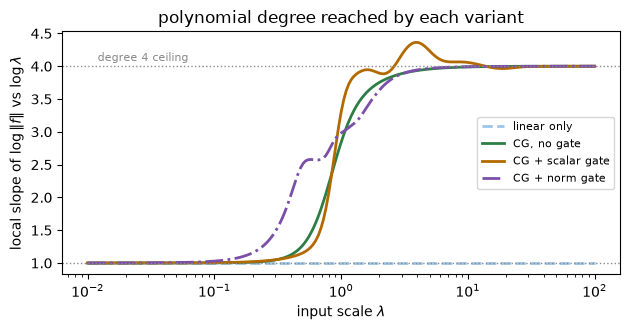

In [58]:
# How nonlinear is the network, and where does that come from?

def net_no_gate(theta, U, V):
    """The same network with the scalar gate removed: couplings and channel mixing only."""
    first_params, _, second_params = unflatten(theta, SPECS)  # Skip the gate parameter block.
    inputs = {1: np.stack([cart_to_sph(U), cart_to_sph(V)], axis=1)}  # Same packing as net_sph.
    hidden = layer_forward(first_params, inputs, M_HID)  # First layer: linear paths plus CG couplings.
    outputs = layer_forward(second_params, hidden, M_OUT)  # Second layer, no nonlinearity in between.
    return np.asarray(sph_to_cart(outputs[1][:, 0])).real  # Cartesian prediction, as in net().

def net_linear_only(theta, U, V):
    """Gate removed AND every tensor-product weight zeroed: only equivariant linear paths survive."""
    blocks = unflatten(theta.copy(), SPECS)  # Copy so the shared theta0 is never modified.
    stripped = [{k: (np.zeros_like(w) if k[0] == 'tp' else w) for k, w in block.items()}
                for block in blocks]  # Delete the couplings, keep the channel mixing.
    return net_no_gate(flatten(stripped), U, V)  # Run the de-gated network on the stripped weights.

lams = np.logspace(-2, 2, 201)  # Scan four decades of input scale.
U0, V0 = np.random.default_rng(4).normal(size=(2, 64, 3))  # One fixed batch, rescaled below.

def degree_curve(f):
    """Return the local log-log slope d(log||f||)/d(log lambda), which reads as a degree."""
    norms = np.array([np.linalg.norm(f(theta0, lam*U0, lam*V0)) for lam in lams])  # Rescale inputs.
    return np.gradient(np.log(norms), np.log(lams))  # Local slope = local polynomial degree.

# A second, equally legal gate: let it see ||x||^2 for each l>0 channel as well as the
# l=0 scalars. Both are invariant, so both are equivariance-safe; they differ in how fast
# their argument grows with the input scale, and that turns out to be visible below.
SPECS_N = [layer_spec(M_IN, M_HID), gate_spec(M_HID, use_norms=True), layer_spec(M_HID, M_OUT)]
# Share BOTH layers with theta0 and redraw only the gate, so the scalar/norm comparison
# differs in exactly the component under test. The gate block itself cannot be shared:
# its Wg is (n_gates, C_0) for scalars alone and (n_gates, C_0 + n_gates) with the norms.
first_0, _, second_0 = unflatten(theta0, SPECS)  # The layers the scalar-gate network uses.
gate_N = init_params([gate_spec(M_HID, use_norms=True)],
                     np.random.default_rng(0))[0]  # Only the gate is drawn fresh.
theta0_N = flatten([first_0, gate_N, second_0])  # Same layers, different gate.

def net_norm(U, V):  # Same architecture, norm-aware gate.
    first, gate, second = unflatten(theta0_N, SPECS_N)  # Unpack the norm-gate parameters.
    inputs = {1: np.stack([cart_to_sph(U), cart_to_sph(V)], axis=1)}  # Same input packing.
    hidden = gate_forward(gate, layer_forward(first, inputs, M_HID), M_HID, use_norms=True)
    return np.asarray(sph_to_cart(layer_forward(second, hidden, M_OUT)[1][:, 0])).real

curves = {'linear only': degree_curve(net_linear_only),  # No couplings: pure linear network.
          'CG, no gate': degree_curve(net_no_gate),  # Couplings, but no activation anywhere.
          'CG + scalar gate': degree_curve(net),  # The architecture as built in Section 1.
          'CG + norm gate': degree_curve(lambda th, U, V: net_norm(U, V))}  # theta is ignored here.

print(f"{'lambda':>10}" + "".join(f"{k:>18s}" for k in curves))
for j in range(0, 201, 25):  # Print a coarse slice of the fine scan.
    print(f"{lams[j]:>10.3g}" + "".join(f"{curves[k][j]:>18.2f}" for k in curves))
print()
for name, c in curves.items():  # Summarize each curve by its range and its shape.
    monotone = bool(np.all(np.diff(c) > -1e-3))  # A polynomial's slope should not fall.
    print(f"  {name:<18s} slope in [{c.min():.3f}, {c.max():.3f}]   monotone: {monotone}")

print("\nlinear only      : slope 1 at every scale. With the couplings removed the network is")
print("                   a linear map, and composing linear maps gives a linear map. This is")
print("                   the collapse that forces an ordinary MLP to insert an activation.")
print("CG, no gate      : climbs 1 -> 4, monotonically, and stops exactly at 4. Two coupling")
print("                   layers multiply features twice, so degree four. No activation is")
print("                   involved: the equivariant network is nonlinear before any is added.")
print("both gated nets  : leave that interval and stop being monotone. Same couplings, same")
print("                   degree budget -- the only difference is tanh, so the change in shape")
print("                   is what the activation buys: saturation, which no polynomial has.")
# How much of the above is signal and how much is the particular draw of weights? Repeat
# across seeds and look at which feature survives. This costs seconds and is worth doing
# before believing any single number.
print("\n" + "-"*66)
print(f"{'seed':>5}{'scalar gate  [min, max]':>28}{'mono':>7}{'norm gate  [min, max]':>26}{'mono':>7}")
for seed in range(6):  # Six initialisations; within a row the two nets share their layers.
    row = f"{seed:>5}"
    base = init_params(SPECS, np.random.default_rng(seed))  # Layers plus a scalar gate.
    gate_n = init_params([gate_spec(M_HID, use_norms=True)],
                         np.random.default_rng(seed))[0]  # Norm gate for the same seed.
    pair = ((flatten(base), SPECS, False),  # Scalar gate.
            (flatten([base[0], gate_n, base[2]]), SPECS_N, True))  # Same layers, norm gate.
    for th, spec, use_n in pair:  # The two gates now differ ONLY in the gate block.
        def f(U, V, th=th, spec=spec, use_n=use_n):  # Bind loop variables into the closure.
            a, b, c = unflatten(th, spec)  # Unpack layer, gate, layer.
            inp = {1: np.stack([cart_to_sph(U), cart_to_sph(V)], axis=1)}  # Pack the inputs.
            h = gate_forward(b, layer_forward(a, inp, M_HID), M_HID, use_norms=use_n)  # Gate.
            return np.asarray(sph_to_cart(layer_forward(c, h, M_OUT)[1][:, 0])).real  # Output.
        cv = degree_curve(lambda th_, U, V, f=f: f(U, V))  # Reuse the scan above.
        row += f"{f'[{cv.min():.3f}, {cv.max():.3f}]':>28}{str(bool(np.all(np.diff(cv) > -1e-3))):>7}"
    print(row)

print("\nRead the two columns of numbers and the two columns of True/False differently.")
print("The over- and undershoot MAGNITUDES are initialisation noise: the same architecture")
print("gives a maximum slope depending only on the random weights.")
print("Quoting one of them as a result would be quoting a seed.")
print("\nWhat is robust is the SHAPE. Every gated run is non-monotone; the un-gated network is")
print("monotone to machine precision, every time. That is the discriminator, and it needs no")
print("claim about what a polynomial can or cannot do -- only the contrast between two")
print("networks that differ in one component.")
print("\nWhich is worth stating plainly, because the tempting argument is wrong: 'a degree-4")
print("polynomial cannot exceed slope 4' is not a theorem. Cancellation between terms of an")
print("inhomogeneous polynomial can push the local slope outside [1,4] transiently. The")
print("monotonicity contrast survives that objection; an overshoot number does not.")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6.4, 3.4))  # One panel is enough to make the point.
    styles = {'linear only': ('#9ec5e8', '--'), 'CG, no gate': ('#2E7D46', '-'),
              'CG + scalar gate': ('#B26A00', '-'),
              'CG + norm gate': ('#7B4FA8', '-.')}  # Fixed colours, readable in print.
    for name, c in curves.items():  # Draw one degree curve per variant.
        color, ls = styles[name]
        ax.plot(lams, c, ls, color=color, lw=2, label=name)
    ax.axhline(4, color='#8a8a8a', lw=1, ls=':')  # Mark the degree ceiling of two coupling layers.
    ax.text(0.012, 4.08, 'degree 4 ceiling', fontsize=8, color='#8a8a8a')  # Label that ceiling.
    ax.set_xscale('log')  # The scan is logarithmic in input scale.
    ax.set_xlabel(r'input scale $\lambda$')  # Horizontal axis is the rescaling factor.
    ax.set_ylabel(r'local slope of $\log\|f\|$ vs $\log\lambda$')  # Vertical axis reads as a degree.
    ax.set_title('polynomial degree reached by each variant')  # State what the figure shows.
    ax.axhline(1, color='#8a8a8a', lw=1, ls=':')  # Mark the lowest degree present.
    ax.legend(fontsize=8)  # Identify the four curves.
    fig.tight_layout()  # Avoid clipped axis labels.
    plt.show()  # Display inside the notebook.
except Exception as exc:  # Keep the numerical result usable without matplotlib.
    print('plotting skipped:', exc)


### Why the slope moves at all

The table above invites a fair objection. A homogeneous map obeys $f(\lambda x)=\lambda^{d}f(x)$, so its
log--log slope is the constant $d$: a straight line, not a ramp. If the network has a degree, why does the
measured degree change with $\lambda$?

Because the network is not homogeneous. Each *path* through it is, but the output is a **sum over paths**,
and the paths do not share a degree:

| where | what it does | degree of its output |
|---|---|---|
| layer 1, `('lin', l)` | mixes channels at fixed $\ell$ | $1$ |
| layer 1, `('tp', ...)` | multiplies two inputs | $2$ |
| layer 2, `('lin', l)` | mixes channels again | $1$ and $2$, whatever arrives |
| layer 2, `('tp', ...)` | multiplies two hidden features | $1{+}1,\;1{+}2,\;2{+}2=2,3,4$ |

So $f(\lambda x)=\lambda c_1+\lambda^{2}c_2+\lambda^{3}c_3+\lambda^{4}c_4$, and no single $d$ satisfies the
scaling law. What the scan measures is a **weighted average of the degrees present**, weighted by whichever
term currently dominates the norm --- the lowest at small $\lambda$, the highest at large $\lambda$. A
homogeneous map is a straight line on a log--log plot; an inhomogeneous one ramps between the line of slope
$1$ and the line of slope $4$. That ramp *is* the curve above.

The cell below does not argue this. It extracts the four $c_d$ and watches the weights shift.


In [59]:
# Extract the homogeneous pieces. If f(lam x) = sum_d lam^d c_d, then evaluating f at
# DMAX+1 distinct scales gives a Vandermonde system whose solution is the c_d themselves.
DMAX = 6  # Allow degrees 0..6; the path counting above says only 1..4 should survive.
probe = np.linspace(0.3, 1.7, DMAX + 1)  # Distinct scales, well conditioned at this size.
vals = np.stack([net_no_gate(theta0, t*U0, t*V0) for t in probe])  # (DMAX+1, batch, 3).
coef = np.linalg.solve(np.vander(probe, DMAX + 1, increasing=True),
                       vals.reshape(DMAX + 1, -1)).reshape((DMAX + 1,) + vals.shape[1:])

print("homogeneous pieces of the un-gated network at theta0:")
for d in range(DMAX + 1):  # Report the size of each degree component.
    print(f"   d={d}   ||c_d|| = {np.linalg.norm(coef[d]):10.6f}")
recon = sum(3.0**d * coef[d] for d in range(DMAX + 1))  # Rebuild f at a scale never fitted.
print(f"\nrebuilt at lambda=3 (outside the fit range): max error "
      f"{np.abs(recon - net_no_gate(theta0, 3.0*U0, 3.0*V0)).max():.2e}")

print("\nfraction of ||f|| carried by each degree, beside the slope measured above:")
print(f"{'lambda':>9}" + "".join(f"{'d=%d' % d:>9}" for d in range(1, 5)) + f"{'slope':>9}")
for t in [0.01, 0.1, 0.5, 1.0, 2.0, 10.0, 100.0]:  # A coarse walk across the four decades.
    frac = np.array([np.linalg.norm(t**d * coef[d]) for d in range(1, 5)])  # Unnormalized.
    j = int(np.argmin(np.abs(lams - t)))  # Nearest point of the fine scan in the last cell.
    print(f"{t:>9.3g}" + "".join(f"{x:>9.3f}" for x in frac/frac.sum())
          + f"{curves['CG, no gate'][j]:>9.3f}")

print("\nDegrees 0, 5 and 6 come back exactly zero, which is the path counting confirmed:")
print("two coupling layers can multiply the input at most twice, and layer_forward carries")
print("no bias, so there is no constant term either. Read the slope column against the four")
print("fractions: it is not a degree, it is whichever degree happens to dominate. It reaches")
print("4 only once the d=4 piece has swamped the rest, and returns to 1 when d=1 has.")
print("\nThe gated networks admit no such decomposition at all. tanh is not a polynomial, so")
print("there is no finite set of degrees to average over -- and nothing to hold the slope")
print("inside [1, 4]. That is the same fact Section 4 reads off the shape of their curves.")

homogeneous pieces of the un-gated network at theta0:
   d=0   ||c_d|| =   0.000000
   d=1   ||c_d|| =   4.948987
   d=2   ||c_d|| =   2.298587
   d=3   ||c_d|| =   8.054493
   d=4   ||c_d|| =   6.061068
   d=5   ||c_d|| =   0.000000
   d=6   ||c_d|| =   0.000000

rebuilt at lambda=3 (outside the fit range): max error 4.10e-11

fraction of ||f|| carried by each degree, beside the slope measured above:
   lambda      d=1      d=2      d=3      d=4    slope
     0.01    0.995    0.005    0.000    0.000    1.000
      0.1    0.940    0.044    0.015    0.001    1.002
      0.5    0.558    0.130    0.227    0.085    1.278
        1    0.232    0.108    0.377    0.284    2.840
        2    0.055    0.051    0.357    0.537    3.751
       10    0.001    0.003    0.117    0.879    3.989
      100    0.000    0.000    0.013    0.987    4.000

Degrees 0, 5 and 6 come back exactly zero, which is the path counting confirmed:
two coupling layers can multiply the input at most twice, and layer_forwa

## Try it

1. Count parameters in each path by hand and compare with `n_par`.
2. Add a constant vector bias to the hidden $\ell=1$ block and measure equivariance.
3. Apply `np.tanh` componentwise to that block and repeat.
4. Change only the learned weights. Explain why equivariance remains at roundoff.
5. In Section 4, raise `M_HID` to `{0: 3, 1: 3, 2: 3}` and rerun. Does the degree ceiling
   move? Now add a third layer instead. Which change moves it, and why?